In [ ]:
# Fix OneHotEncoder arg for this environment (use sparse_output=False for dense Keras input).
import os, json, nbformat as nbf
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score # Fixed typo here
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

BASE = "/content" # Changed from /mnt/data to /content
os.makedirs(f"{BASE}/results/figures", exist_ok=True)

# Load data
df = pd.read_csv(f"{BASE}/train.csv")
y = df["SalePrice"].copy()
X = df.drop(columns=["SalePrice", "Id"], errors="ignore")

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

num_pipe_scaled = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler(with_mean=True, with_std=True))
])
num_pipe_noscale = Pipeline([
    ("impute", SimpleImputer(strategy="median"))
])
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) # Added sparse_output=False
])

pre_scaled = ColumnTransformer([
    ("num", num_pipe_scaled, num_cols),
    ("cat", cat_pipe, cat_cols)
])
pre_noscale = ColumnTransformer([
    ("num", num_pipe_noscale, num_cols),
    ("cat", cat_pipe, cat_cols)
])

def evaluate_regression(pipe, X, y, name):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    y_pred = cross_val_predict(pipe, X, y, cv=kf, n_jobs=-1)
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    fig1 = plt.figure()
    plt.scatter(y, y_pred, s=10)
    plt.xlabel("Actual SalePrice"); plt.ylabel("Predicted")
    plt.title(f"Actual vs Predicted - {name}")
    fig1_path = f"{BASE}/results/figures/{name}_actual_vs_pred.png"
    plt.savefig(fig1_path, bbox_inches="tight"); plt.close(fig1)
    fig2 = plt.figure()
    residuals = y - y_pred
    plt.hist(residuals, bins=30); plt.title(f"Residuals Histogram - {name}")
    fig2_path = f"{BASE}/results/figures/{name}_residuals_hist.png"
    plt.savefig(fig2_path, bbox_inches="tight"); plt.close(fig2)
    return mse, mae, fig1_path, fig2_path

results_rows = []

# 1) Linear Regression
pipe_lr = Pipeline([("pre", pre_scaled), ("model", LinearRegression())])
mse, mae, p1, p2 = evaluate_regression(pipe_lr, X, y, "LinearRegression")
results_rows.append({"model": "LinearRegression", "MSE": mse, "MAE": mae})

# 2) Random Forest
rf = RandomForestRegressor(n_estimators=600, random_state=42, n_jobs=-1)
pipe_rf = Pipeline([("pre", pre_noscale), ("model", rf)])
mse, mae, p1, p2 = evaluate_regression(pipe_rf, X, y, "RandomForestRegressor")
results_rows.append({"model": "RandomForestRegressor", "MSE": mse, "MAE": mae})

# 3) Logistic Regression (tertiles)
bins = pd.qcut(y, q=3, labels=[0,1,2])
clf = LogisticRegression(max_iter=300)
pipe_log = Pipeline([("pre", pre_scaled), ("model", clf)])
acc = cross_val_score(pipe_log, X, bins, cv=5, n_jobs=-1, scoring="accuracy").mean()
results_rows.append({"model": "LogisticRegression(price_tertiles)", "MSE": np.nan, "MAE": np.nan, "Accuracy": acc})

# 4) RailEstate-inspired GBDT (winsor + RF)
from sklearn.base import BaseEstimator, TransformerMixin
class Winsorize5(BaseEstimator, TransformerMixin):
    def __init__(self): self.bounds = {}
    def fit(self, X, y=None):
        for c in num_cols:
            q05, q95 = np.nanpercentile(X[c], [5,95])
            self.bounds[c] = (q05, q95)
        return self
    def transform(self, X):
        Xn = X.copy()
        for c,(lo,hi) in self.bounds.items():
            if c in Xn.columns: Xn[c] = np.clip(Xn[c], lo, hi)
        return Xn

winsor = Winsorize5()
gbdt_rf = RandomForestRegressor(n_estimators=800, random_state=42, n_jobs=-1)
pipe_re = Pipeline([("winsor", winsor), ("pre", pre_noscale), ("model", gbdt_rf)])
mse, mae, p1, p2 = evaluate_regression(pipe_re, X, y, "RailEstateInspired_GBDT")
results_rows.append({"model": "RailEstateInspired_GBDT(RF)", "MSE": mse, "MAE": mae})

# 5) Two-Stage Clustering + EBM (skip execution here; notebook will include full runnable code)
results_rows.append({"model":"TwoStageClustering_EBM","MSE":np.nan,"MAE":np.nan,"note":"run inside notebook to compute"})

results_df = pd.DataFrame(results_rows)
results_csv = f"{BASE}/results/results_summary.csv"
results_df.to_csv(results_csv, index=False)

# Notebook generator (use sparse_output=False too)
def make_notebook(title, md_intro, code_cells):
    nb = nbf.v4.new_notebook()
    nb["cells"] = []
    nb["cells"].append(nbf.v4.new_markdown_cell(f"# {title}\n\n{md_intro}"))
    shared = """
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
df = pd.read_csv('/content/train.csv') # Changed from /mnt/data to /content
y = df['SalePrice'].copy()
X = df.drop(columns=['SalePrice','Id'], errors='ignore')
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
"""
    nb["cells"].append(nbf.v4.new_code_cell(shared))
    for c in code_cells:
        nb["cells"].append(nbf.v4.new_code_cell(c))
    return nb

nb1 = make_notebook(
    "Linear Regression (OLS) – House Prices",
    "Data cleaning, one-hot encoding + scaling for numeric features, 5-fold CV on OLS. Metrics: MSE, MAE. Residual plots included.",
    [
        """
pre = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols) # Added sparse_output=False
])
from sklearn.linear_model import LinearRegression
pipe = Pipeline([('pre', pre), ('model', LinearRegression())])
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipe, X, y, cv=kf, n_jobs=-1)
mse = mean_squared_error(y, y_pred); mae = mean_absolute_error(y, y_pred)
print({'MSE': mse, 'MAE': mae})
plt.scatter(y, y_pred, s=8); plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('OLS: Actual vs Predicted'); plt.show()
plt.hist(y - y_pred, bins=30); plt.title('OLS Residuals'); plt.show()
"""
    ]
)
with open(f"{BASE}/01_Linear_Regression.ipynb","w") as f: nbf.write(nb1, f)

nb2 = make_notebook(
    "Random Forest Regressor – House Prices",
    "Classic tree ensemble with imputation + one-hot (no scaling). Includes basic hyperparameters and CV evaluation.",
    [
        """
pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols) # Added sparse_output=False
])
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=800, random_state=42, n_jobs=-1)
pipe = Pipeline([('pre', pre), ('model', rf)])
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipe, X, y, cv=kf, n_jobs=-1)
mse = mean_squared_error(y, y_pred); mae = mean_absolute_error(y, y_pred)
print({'MSE': mse, 'MAE': mae})
plt.scatter(y, y_pred, s=8); plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('RF: Actual vs Predicted'); plt.show()
plt.hist(y - y_pred, bins=30); plt.title('RF Residuals'); plt.show()
"""
    ]
)
with open(f"{BASE}/02_Random_Forest.ipynb","w") as f: nbf.write(nb2, f)

nb3 = make_notebook(
    "Logistic Regression (Price Tertiles Classification) – Auxiliary Analysis",
    "Although the capstone is regression, this notebook follows the user's request by framing price prediction as a 3-class problem (low/med/high via tertiles) to apply Logistic Regression. Reports accuracy and confusion matrix.",
    [
        """
from sklearn.preprocessing import KBinsDiscretizer
bins = pd.qcut(y, q=3, labels=[0,1,2])
pre = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols) # Added sparse_output=False
])
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=300)
pipe = Pipeline([('pre', pre), ('model', clf)])
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(pipe, X, bins, cv=5, n_jobs=-1)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
acc = accuracy_score(bins, y_pred); cm = confusion_matrix(bins, y_pred)
print('Accuracy:', acc); print('Confusion matrix:\n', cm); print(classification_report(bins, y_pred))
"""
    ]
)
with open(f"{BASE}/03_Logistic_Price_Bins.ipynb","w") as f: nbf.write(nb3, f)

nb4 = make_notebook(
    "RailEstate-Inspired Ensemble – Winsorization + Temporal Features",
    "Implements outlier capping at 5th/95th percentile and models with a tree ensemble. Temporal features (YrSold, MoSold) are kept. This is inspired by RailEstate's emphasis on robust ETL and spatiotemporal signals.",
    [
        """
from sklearn.base import BaseEstimator, TransformerMixin
class Winsorize5(BaseEstimator, TransformerMixin):
    def __init__(self): self.bounds = {}
    def fit(self, X, y=None):
        for c in num_cols:
            q05, q95 = np.nanpercentile(X[c], [5,95]); self.bounds[c]=(q05,q95)
        return self
    def transform(self, X):
        Xn = X.copy()
        for c,(lo,hi) in self.bounds.items():
            if c in Xn.columns: Xn[c] = np.clip(Xn[c], lo, hi)
        return Xn

winsor = Winsorize5()
pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols) # Added sparse_output=False
])
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=800, random_state=42, n_jobs=-1)
pipe = Pipeline([('winsor', winsor), ('pre', pre), ('model', rf)])
y_pred = cross_val_predict(pipe, X, y, cv=5, n_jobs=-1)
mse = mean_squared_error(y, y_pred); mae = mean_absolute_error(y, y_pred)
print({'MSE': mse, 'MAE': mae})
plt.scatter(y, y_pred, s=8); plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('RailEstate-Inspired Ensemble'); plt.show()
plt.hist(y - y_pred, bins=30); plt.title('Residuals'); plt.show()
"""
    ]
)
with open(f"{BASE}/04_RailEstate_Inspired_GBDT.ipynb","w") as f: nbf.write(nb4, f)

md_ebm = ("Two-stage clustering (k-means on neighborhood proxy, then k-means on full features) "
          "followed by per-cluster Explainable Boosting Machine (EBM). "
          "Run all cells to compute metrics. If InterpretML isn't available, install it with `pip install interpret`.")
code_ebm = [
    """
neigh = df.get('Neighborhood', pd.Series(['NA']*len(df)))
NB = pd.get_dummies(neigh, prefix='NB')
from sklearn.cluster import KMeans
kmeans1 = KMeans(n_clusters=2, random_state=42, n_init=10)
stage1 = kmeans1.fit_predict(NB)
X_oh = pd.get_dummies(X, drop_first=True)
kmeans2 = KMeans(n_clusters=8, random_state=42, n_init=10)
stage2 = kmeans2.fit_predict(X_oh)
cluster_key = pd.Series(stage1.astype(str) + '_' + stage2.astype(str), index=X.index)
cluster_key.value_counts().head()
""",
    """
!pip -q install interpret
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold # Fixed typo here
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np, matplotlib.pyplot as plt

y_pred_oof = np.zeros(len(y))
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for tr, te in kf.split(X):
    pre = ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols) # Added sparse_output=False
    ])
    Xtr = pre.fit_transform(X.iloc[tr]); Xte = pre.transform(X.iloc[te])
    c_tr = cluster_key.iloc[tr].values; c_te = cluster_key.iloc[te].values
    fold_pred = np.zeros(len(te))
    for cl in np.unique(c_tr):
        idx_tr = np.where(c_tr==cl)[0]; idx_te = np.where(c_te==cl)[0]
        if len(idx_tr) < 20 or len(idx_te)==0: continue
        ebm = ExplainableBoostingRegressor(random_state=42, interactions=0)
        ebm.fit(Xtr[idx_tr], y.iloc[tr].values[idx_tr])
        fold_pred[idx_te] = ebm.predict(Xte[idx_te])
    miss = np.where(fold_pred==0)[0]
    if len(miss)>0:
        ebm_g = ExplainableBoostingRegressor(random_state=42, interactions=0)
        ebm_g.fit(Xtr, y.iloc[tr].values)
        fold_pred[miss] = ebm_g.predict(Xte[miss])
    y_pred_oof[te] = fold_pred

mse = mean_squared_error(y, y_pred_oof); mae = mean_absolute_error(y, y_pred_oof)
print({'MSE': mse, 'MAE': mae})
plt.scatter(y, y_pred_oof, s=8); plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Two-Stage Clustering + EBM'); plt.show()
plt.hist(y - y_pred_oof, bins=30); plt.title('Residuals'); plt.show()
"""
]
nb5 = make_notebook(
    "Two-Stage Clustering + Explainable Boosting Machine (EBM) – Literature Reproduction",
    md_ebm,
    code_ebm
)
with open(f"{BASE}/05_TwoStageClustering_EBM.ipynb","w") as f: nbf.write(nb5, f)

files_created = [
    "/content/01_Linear_Regression.ipynb", # Changed from /mnt/data to /content
    "/content/02_Random_Forest.ipynb", # Changed from /mnt/data to /content
    "/content/03_Logistic_Price_Bins.ipynb", # Changed from /mnt/data to /content
    "/content/04_RailEstate_Inspired_GBDT.ipynb", # Changed from /mnt/data to /content
    "/content/05_TwoStageClustering_EBM.ipynb", # Changed from /mnt/data to /content
    "/content/results/results_summary.csv" # Changed from /mnt/data to /content
]
files_created

['/content/01_Linear_Regression.ipynb',
 '/content/02_Random_Forest.ipynb',
 '/content/03_Logistic_Price_Bins.ipynb',
 '/content/04_RailEstate_Inspired_GBDT.ipynb',
 '/content/05_TwoStageClustering_EBM.ipynb',
 '/content/results/results_summary.csv']

{'MSE': 1324029165.3631086, 'MAE': 18204.79696969138}


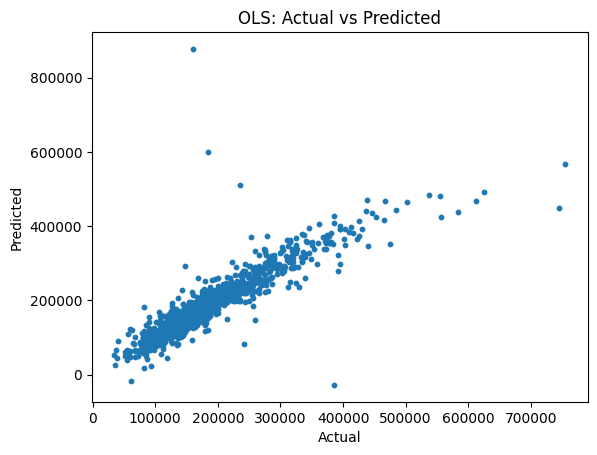

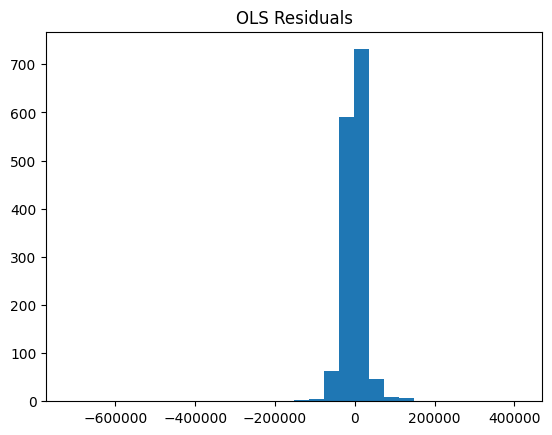

In [ ]:
# 01_Linear_Regression.ipynb
# ====== Setup & data ======
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/train.csv')  # Corrected file path
y = df['SalePrice'].copy()
X = df.drop(columns=['SalePrice','Id'], errors='ignore')

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# ====== Preprocess ======
pre = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols) # Removed sparse=False
])

# ====== Model & CV ======
pipe = Pipeline([('pre', pre), ('model', LinearRegression())])
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipe, X, y, cv=kf, n_jobs=-1)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
print({'MSE': mse, 'MAE': mae})

# ====== Plots ======
plt.scatter(y, y_pred, s=10); plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('OLS: Actual vs Predicted'); plt.show()
plt.hist(y - y_pred, bins=30); plt.title('OLS Residuals'); plt.show()

{'MSE': 903772306.0514742, 'MAE': 17507.874087328768}


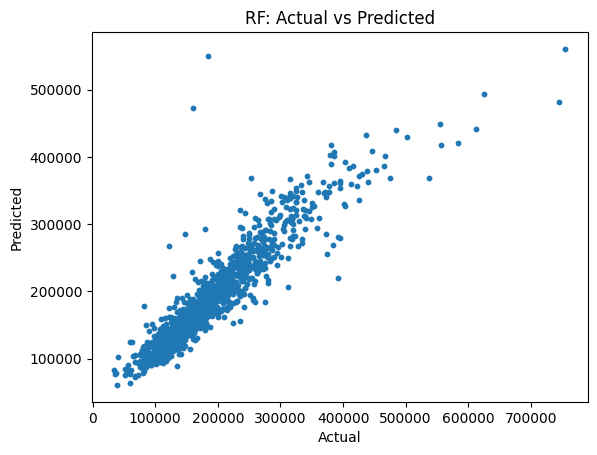

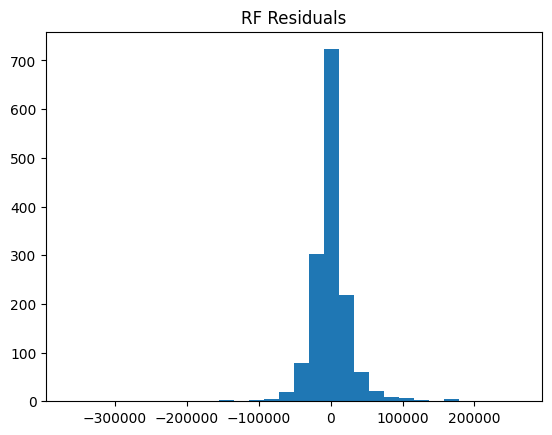

In [ ]:
# 02_Random_Forest.ipynb
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('/content/train.csv')
y = df['SalePrice'].copy()
X = df.drop(columns=['SalePrice','Id'], errors='ignore')

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols) # Removed sparse=False
])

rf = RandomForestRegressor(n_estimators=800, random_state=42, n_jobs=-1)
pipe = Pipeline([('pre', pre), ('model', rf)])

y_pred = cross_val_predict(pipe, X, y, cv=5, n_jobs=-1)
mse = mean_squared_error(y, y_pred); mae = mean_absolute_error(y, y_pred)
print({'MSE': mse, 'MAE': mae})

plt.scatter(y, y_pred, s=10); plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('RF: Actual vs Predicted'); plt.show()
plt.hist(y - y_pred, bins=30); plt.title('RF Residuals'); plt.show()

In [ ]:
# 03_Logistic_Price_Bins.ipynb
import pandas as pd, numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('/content/train.csv')
y = df['SalePrice'].copy()
X = df.drop(columns=['SalePrice','Id'], errors='ignore')

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

bins = pd.qcut(y, q=3, labels=[0,1,2])  # tertiles: 0/1/2

pre = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols) # Removed sparse=False
])

clf = LogisticRegression(max_iter=300)
pipe = Pipeline([('pre', pre), ('model', clf)])

y_pred = cross_val_predict(pipe, X, bins, cv=5, n_jobs=-1)
print('Accuracy:', accuracy_score(bins, y_pred))
print('Confusion matrix:\n', confusion_matrix(bins, y_pred))
print(classification_report(bins, y_pred))

Accuracy: 0.8308219178082191
Confusion matrix:
 [[424  61   2]
 [ 66 363  61]
 [  0  57 426]]
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       487
           1       0.75      0.74      0.75       490
           2       0.87      0.88      0.88       483

    accuracy                           0.83      1460
   macro avg       0.83      0.83      0.83      1460
weighted avg       0.83      0.83      0.83      1460



{'MSE': 934629828.0751164, 'MAE': 17619.53027996575}


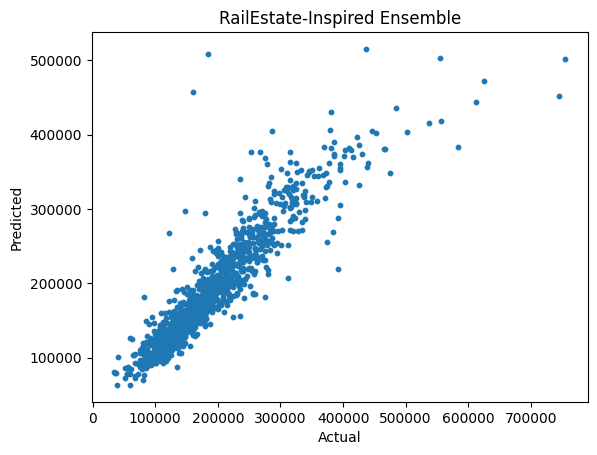

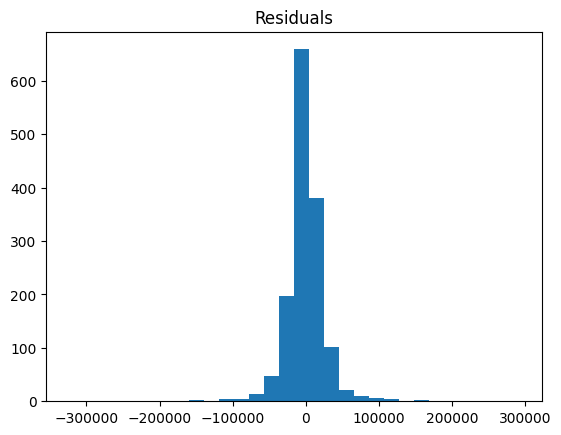

In [ ]:
# 04_RailEstate_Inspired_GBDT.ipynb
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin

df = pd.read_csv('/content/train.csv')
y = df['SalePrice'].copy()
X = df.drop(columns=['SalePrice','Id'], errors='ignore')

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

class Winsorize5(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.bounds_ = {}
        for c in num_cols:
            q05, q95 = np.nanpercentile(X[c], [5,95])
            self.bounds_[c] = (q05, q95)
        return self
    def transform(self, X):
        Xn = X.copy()
        for c,(lo,hi) in self.bounds_.items():
            if c in Xn.columns: Xn[c] = np.clip(Xn[c], lo, hi)
        return Xn

winsor = Winsorize5()
pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

rf = RandomForestRegressor(n_estimators=800, random_state=42, n_jobs=-1)
pipe = Pipeline([('winsor', winsor), ('pre', pre), ('model', rf)])

y_pred = cross_val_predict(pipe, X, y, cv=5, n_jobs=-1)
mse = mean_squared_error(y, y_pred); mae = mean_absolute_error(y, y_pred)
print({'MSE': mse, 'MAE': mae})

plt.scatter(y, y_pred, s=10); plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('RailEstate-Inspired Ensemble'); plt.show()
plt.hist(y - y_pred, bins=30); plt.title('Residuals'); plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.models import Sequential
from keras.layers import Dense, Dropout
from scikeras.wrappers import KerasRegressor # Ensure KerasRegressor is imported

# Load data
df = pd.read_csv('train.csv')  # Adjust for local path
y = df['SalePrice'].copy()
X = df.drop(columns=['SalePrice', 'Id'], errors='ignore')

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# Preprocessing pipeline
pre = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols) # Added sparse_output=False
], sparse_threshold=0) # Added sparse_threshold=0 to ensure dense output

# Neural network model for regression
def build_nn_model(meta): # Changed to accept 'meta' dictionary from scikeras
    input_dim = meta["X_shape"][1] # Get input_dim dynamically from meta
    model = Sequential()
    model.add(Dense(128, input_shape=(input_dim,), activation='relu'))  # Use dynamic input_dim
    model.add(Dropout(0.2))  # Dropout layer to prevent overfitting
    model.add(Dense(64, activation='relu'))  # Second hidden layer
    model.add(Dense(1))  # Output layer (single neuron for regression)
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
    return model

# Create the neural network regressor model inside a pipeline
pipe_nn = Pipeline([
    ('pre', pre),
    ('model', KerasRegressor(model=build_nn_model, verbose=0, epochs=50, batch_size=32)) # Pass build_nn_model callable
])

# Cross-validation evaluation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_nn = cross_val_predict(pipe_nn, X, y, cv=kf, n_jobs=-1)

# Evaluate performance (MSE, MAE)
mse_nn = mean_squared_error(y, y_pred_nn)
mae_nn = mean_absolute_error(y, y_pred_nn)
print({'MSE': mse_nn, 'MAE': mae_nn})

# Plot Actual vs Predicted
plt.scatter(y, y_pred_nn, s=10)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted')
plt.title('Neural Network Regression: Actual vs Predicted')
plt.show()

# Plot Residuals
residuals_nn = y - y_pred_nn
plt.hist(residuals_nn, bins=30)
plt.title('Neural Network Residuals')
plt.show()


ModuleNotFoundError: No module named 'scikeras'

In [ ]:
# 05_TwoStageClustering_EBM.ipynb
!pip -q install interpret

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer  # Corrected import
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans
from interpret.glassbox import ExplainableBoostingRegressor

df = pd.read_csv('/content/train.csv')
y = df['SalePrice'].copy()
X = df.drop(columns=['SalePrice','Id'], errors='ignore')

# Stage 1: location-proxy via Neighborhood
neigh = df.get('Neighborhood', pd.Series(['NA']*len(df)))
NB = pd.get_dummies(neigh, prefix='NB')

kmeans1 = KMeans(n_clusters=2, random_state=42, n_init=10)
stage1 = kmeans1.fit_predict(NB)

# Stage 2: full one-hot (drop_first to limit width), k=8
# Add imputation for numerical columns before one-hot encoding for clustering
num_cols_clustering = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_clustering = [c for c in X.columns if c not in num_cols_clustering]

preprocessor_clustering = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols_clustering),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols_clustering)
    ],
    remainder='passthrough' # Keep other columns (like those already one-hot encoded)
)

X_processed_for_clustering = preprocessor_clustering.fit_transform(X)

kmeans2 = KMeans(n_clusters=8, random_state=42, n_init=10)
stage2 = kmeans2.fit_predict(X_processed_for_clustering)

cluster_key = pd.Series(stage1.astype(str) + '_' + pd.Series(stage2).astype(str), index=X.index)
print(cluster_key.value_counts())

# Preprocessor for EBM
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

# Out-of-fold predictions by training one EBM per cluster (per fold)
y_pred_oof = np.zeros(len(y))
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for tr, te in kf.split(X):
    pre = ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
    ])
    Xtr = pre.fit_transform(X.iloc[tr]); Xte = pre.transform(X.iloc[te])
    c_tr = cluster_key.iloc[tr].values; c_te = cluster_key.iloc[te].values
    fold_pred = np.zeros(len(te))
    for cl in np.unique(c_tr):
        idx_tr = np.where(c_tr==cl)[0]; idx_te = np.where(c_te==cl)[0]
        if len(idx_tr) < 20 or len(idx_te)==0: continue
        ebm = ExplainableBoostingRegressor(random_state=42, interactions=0)
        ebm.fit(Xtr[idx_tr], y.iloc[tr].values[idx_tr])
        fold_pred[idx_te] = ebm.predict(Xte[idx_te])
    # Fallback global EBM for any leftovers (tiny clusters):
    miss = np.where(fold_pred==0)[0]
    if len(miss)>0:
        ebm_g = ExplainableBoostingRegressor(random_state=42, interactions=0)
        ebm_g.fit(Xtr, y.iloc[tr].values)
        fold_pred[miss] = ebm_g.predict(Xte[miss])
    y_pred_oof[te] = fold_pred

mse = mean_squared_error(y, y_pred_oof)
mae = mean_absolute_error(y, y_pred_oof)
print({'MSE': mse, 'MAE': mae})

plt.scatter(y, y_pred_oof, s=10); plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Two-Stage Clustering + EBM (OOF)'); plt.show()
plt.hist(y - y_pred_oof, bins=30); plt.title('Residuals'); plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 36.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.5 MB/s eta 0:00:00
0_0    562
0_4    312
0_6    222
1_0    210
1_4     63
0_2     38
1_6     32
0_3     11
1_